# Exploration ProGEDO — quelles variables expliquent le choix de la **marche** ?

**Notebook d'analyse exploratoire**, pendant de `explore_progedo_bike_shapley.ipynb`.
Même protocole, même modèle, même découpage en blocs — cible `walk` au lieu de `bike`.
La référence de production reste `prepare_progedo_logit.ipynb`.

## Pourquoi la marche pose un problème différent du vélo
Le vélo est un mode **rare** (3,9 %) : la difficulté était le déséquilibre de classe et
les variables manquantes. La marche est un mode **massif** (27,8 % des déplacements) et
presque entièrement **contraint par la distance**. La question n'est donc pas « le modèle
sait-il prédire la marche ? » — il le sait trop bien — mais :

> à distance donnée, **qui** marche et **pourquoi** ?

## ⚠️ Avertissement méthodologique : les deux variables de distance sont inutilisables ici

Le notebook vélo avait mesuré des facteurs de détour `D12/D11` de 1.15 pour la marche
contre 1.40–1.51 pour les autres modes, et conclu — à raison pour une cible vélo — que
« seule la marche est trahie ». **Pour une cible marche, cette trahison est fatale**, et
elle est bien pire que ce que le facteur de détour laissait supposer :

- **D12** (distance sur le réseau du mode utilisé) porte la signature du mode ;
- **D11**, présenté comme « vol d'oiseau mode-neutre », **n'est pas mesuré pour les
  déplacements à pied** : il vaut exactement `durée déclarée (D9) × 58 m/min`. Le §7
  le démontre. La variable n'encode pas une géographie, elle encode une durée de marche.

Utiliser l'une ou l'autre donne une PR-AUC de **0.98** — un artefact, pas un résultat.

**Correctif retenu :** une distance origine-destination reconstruite depuis le shapefile
des zones fines, `od_km` = distance euclidienne entre centroïdes de la ZF d'origine (`D3`)
et de destination (`D7`), avec un proxy `0.5 × √surface` pour les déplacements intra-zone.
Elle est **identique quel que soit le mode** — corrélée à 0.995 avec D11 hors marche —
et ne peut donc rien trahir. Prix à payer : elle n'existe que pour les zones du périmètre
d'enquête, soit **51 % des déplacements**.

## Les choix de méthode repris du notebook vélo

**a. Cible binaire `walk` vs reste, métrique PR-AUC**, lue contre le taux de base.

**b. Séparation Block A / Block B** selon le critère *l'information est-elle connue avant
la décision ?* — Block A exogène (leviers), Block B habitudes déclarées (quasi-tautologique,
mais c'est ce que la LTM de l'agent LLM est censée encoder).

⚠️ **Le Block B n'a pas d'équivalent de `freq_bike` pour la marche.** `P19` (fréquence
d'usage de la marche) est **intégralement vide** dans le fichier Toulouse 2023 : 20 890
cellules vides sur 20 890. Le Block B ne contient donc que les fréquences des modes
**concurrents** (`P20` vélo, `P21` 2RM, `P22` VP conducteur, `P24` TC) et le télétravail.
Ce n'est pas un détail de qualité de données — c'est ce qui rend le §12 interprétable.

**c. Séparation train/test par MÉNAGE** (`GroupShuffleSplit` sur `hh_id`).

*(Block C — durée `D9`, nb de trajets `D10` — toujours écarté : dérivé du trajet réalisé.
La contamination de D11 par D9 est précisément la raison de cette exclusion.)*

In [1]:
import warnings; warnings.filterwarnings("ignore")
import pandas as pd, numpy as np, geopandas as gpd
import matplotlib.pyplot as plt
import lightgbm as lgb, shap
from pathlib import Path
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import average_precision_score, roc_auc_score

pd.set_option("display.max_columns", 80)
WALK = "#0891b2"   # palette projet : la marche est en cyan

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT/"data"/"PROGEDO 2023").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
PROGEDO_DIR = PROJECT_ROOT/"data"/"PROGEDO 2023"/"lil-1750-Donnees_CSV"/"fichiers_standards"
SIG_ZF      = PROJECT_ROOT/"data"/"PROGEDO 2023"/"lil-1750-Documentation"/"SIG"/"EMC2_Toulouse_2023_ZF_26052023.shp"
OUT_DIR     = PROJECT_ROOT/"scripts"/"progedo_logit"
assert PROGEDO_DIR.exists() and SIG_ZF.exists()
print("OK :", PROGEDO_DIR)

OK : /Users/yvesb/Documents/Projects/llm-agents-gama/data/PROGEDO 2023/lil-1750-Donnees_CSV/fichiers_standards


## 1. Chargement

In [2]:
pers = pd.read_csv(PROGEDO_DIR/"Toulouse_2023_std_pers.csv", dtype=str)
men  = pd.read_csv(PROGEDO_DIR/"Toulouse_2023_std_men.csv",  dtype=str)
depl = pd.read_csv(PROGEDO_DIR/"Toulouse_2023_std_depl.csv", dtype=str)

# Codes ProGEDO : zéros de tête significatifs, cellules vides = non-enquêté.
for df_ in (pers, men, depl):
    for c in df_.columns:
        df_[c] = df_[c].str.strip().replace({"": np.nan})

print("pers:", pers.shape, "| men:", men.shape, "| depl:", depl.shape)
print("\nTaux de remplissage des fréquences d'usage déclarées (Block B candidat) :")
for v, lib in [("P19","marche"),("P20","vélo"),("P21","2-roues motorisé"),
               ("P22","VP conducteur"),("P23","VP passager"),("P24","transports urbains")]:
    print(f"  {v} ({lib:18s}) : {pers[v].notna().mean()*100:5.1f} %")

pers: (20890, 45) | men: (10783, 77) | depl: (54585, 29)

Taux de remplissage des fréquences d'usage déclarées (Block B candidat) :
  P19 (marche            ) :   0.0 %
  P20 (vélo              ) :  75.5 %
  P21 (2-roues motorisé  ) :  75.5 %
  P22 (VP conducteur     ) :  75.5 %
  P23 (VP passager       ) :   0.0 %
  P24 (transports urbains) :  75.5 %


`P19` et `P23` sont vides. **La fréquence d'usage de la marche n'existe pas dans ce jeu de
données** — la variable qui, pour le vélo, dominait tout le modèle n'a pas de contrepartie.

## 2. Bloc géographique — densité, gradient centre/périphérie, et distance OD mode-neutre

Le shapefile des zones fines fournit centroïde (`XL93`/`YL93`) et surface (`SURF_M2`).
On en tire trois choses : la densité de ménages (estimée depuis les coefficients de
redressement `COE0`), la distance à l'hypercentre, et — nouveauté de ce notebook — la
**distance origine-destination `od_km`** qui remplacera D11 et D12.

In [3]:
zf = gpd.read_file(SIG_ZF)[["ZF","XL93","YL93","SURF_M2"]]
zf["ZF"] = zf["ZF"].astype(str).str.strip()

w = men.assign(COE0=pd.to_numeric(men["COE0"], errors="coerce")).groupby("ZFM")["COE0"].sum()
zf["area_km2"]       = zf["SURF_M2"]/1e6
zf["density_hh_km2"] = zf["ZF"].map(w)/zf["area_km2"]

# Hypercentre = centroïde des zones fines du secteur 01 (Capitole)
core = zf[zf["ZF"].str.startswith("1011")]
CX, CY = core["XL93"].mean(), core["YL93"].mean()
zf["dist_center_km"] = np.hypot(zf["XL93"]-CX, zf["YL93"]-CY)/1000

GEO  = zf.set_index("ZF")[["area_km2","density_hh_km2","dist_center_km"]]
XYS  = zf.set_index("ZF")[["XL93","YL93","SURF_M2"]]     # pour od_km
print(f"Hypercentre L93 estimé : X={CX:.0f} Y={CY:.0f}")
GEO.describe().round(1)

Hypercentre L93 estimé : X=574406 Y=6278825


,area_km2,density_hh_km2,dist_center_km
count,785.0,704.0,785.0
mean,6.9,1421.0,19.7
std,8.5,2657.9,14.7
min,0.1,1.5,0.2
25%,0.8,27.4,6.5
50%,4.4,148.1,16.6
75%,9.8,1471.0,31.5
max,66.7,19572.4,61.1


## 3. Dictionnaires de recodage

In [4]:
GENDER    = {"1":"Male","2":"Female"}
MAIN_OCC  = {"1":"Travail plein temps","2":"Travail temps partiel","3":"Alternance/stage",
             "4":"Étudiant","5":"Scolaire","6":"Chômeur","7":"Retraité","8":"Foyer","9":"Autre"}
SOCIOPRO  = {"01":"Agriculteur","02":"Artisan/Commerçant","03":"Cadre","04":"Interm.",
             "05":"Employé","06":"Ouvrier","07":"Élève/Étudiant","08":"Autre inactif",
             "09":"Autre inactif","00":None}
EDU       = {"00":"En cours","01":"Primaire","02":"Secondaire <bac","03":"Secondaire <bac",
             "04":"Bac","05":"Bac+2","06":"Bac+3 et +","07":"Apprentissage",
             "08":"Apprentissage sup","09":"Pas d'études","90":"Autre",
             "93":"Secondaire nd","97":"Apprentissage nd"}
LIEN      = {"1":"Réf.","2":"Conjoint","3":"Enfant","4":"Coloc/locataire",
             "5":"Autre parenté","6":"Autre sans parenté","7":"Autre"}
HABITAT   = {"1":"Individuel isolé","2":"Individuel accolé","3":"Petit collectif",
             "4":"Grand collectif","5":"Autre"}
OCCUP_LOG = {"1":"Propriétaire","2":"Locataire HLM","3":"Autre locataire","4":"Logé gratuit",
             "5":"Résidence univ.","6":"Autre","7":"Autre","8":"Locataire nd","9":None}
PARK_NUIT = {"1":"Garage/box réservé","2":"Rue","3":"Parc ciel ouvert",
             "4":"Parc couvert public","9":"Autre"}
VP_TRAV   = {"1":"Oui, jusqu'au lieu","2":"Oui, partiel","3":"Oui, non utilisée","4":"Non",
             "5":"Oui, partiel/pas","6":"Oui, tout/partie"}
PARK_VOIT = {"1":"Non","2":"Oui, place réservée","3":"Oui, offre importante",
             "4":"Oui, selon horaires","5":"Ne sait pas"}
FREQ      = {"1":"Plusieurs/semaine","2":"Plusieurs/mois","3":"Occasionnel","4":"Jamais"}
TELETRAV  = {"1":"Jamais","2":"1+ j/semaine","3":"Plusieurs j/mois","4":"Occasionnel"}
JOURS     = {"1":"Lundi","2":"Mardi","3":"Mercredi","4":"Jeudi","5":"Vendredi",
             "6":"Samedi","7":"Dimanche"}

# MODP -> cible. Identique aux deux autres notebooks pour rester comparable.
MODE_GROUP = {
    "01":"walk","93":"walk","94":"walk","96":"walk","97":"walk",
    "10":"bike","11":"bike","12":"bike","17":"bike","18":"bike",
    "21":"car","22":"car","61":"car","62":"car","81":"car","82":"car",
    "13":"car","14":"car","15":"car","16":"car","19":"car","20":"car",
    "31":"transit","32":"transit","33":"transit","34":"transit","37":"transit",
    "38":"transit","39":"transit","41":"transit","42":"transit","43":"transit",
    "51":"transit","52":"transit","53":"transit","54":"transit","71":"transit",
}

def purpose(c):
    if c in ("01","02"):                                              return "home"
    if c in ("11","12","13","14","81"):                               return "work"
    if c in ("21","22","23","24","25","26","27","28","29","96","97"): return "education"
    if c in ("30","31","32","33","34","35","82","98"):                return "shop"
    if c in ("51","52","53","54"):                                    return "leisure"
    return "other"

## 4. Table ménage

Identique au notebook vélo, moins `M23` (stationnement vélo au domicile) : sans objet pour
la marche. On conserve `M12A` (stationnement nocturne de la voiture), qui pour la marche se
lit comme un **coût de sortie de la voiture** : quand la voiture dort dans la rue, la
reprendre pour 800 m coûte une place de stationnement.

In [5]:
men_feat = pd.DataFrame({
    "ZF": men["ZFM"], "ECH": men["ECH"],
    "number_of_cars":    pd.to_numeric(men["M6"],  errors="coerce"),
    "n_bikes":           pd.to_numeric(men["M21"], errors="coerce"),
    "n_motorbikes":      pd.to_numeric(men["M14"], errors="coerce"),
    "housing_type":      men["M1"].map(HABITAT),
    "housing_tenure":    men["M2"].map(OCCUP_LOG),
    "car_night_parking": men["M12A"].map(PARK_NUIT),
}).drop_duplicates(["ZF","ECH"])
men_feat["has_bike"] = men_feat["n_bikes"].fillna(0) > 0
print(men_feat.shape); men_feat.head(3)

(10783, 9)


,ZF,ECH,number_of_cars,n_bikes,n_motorbikes,housing_type,housing_tenure,car_night_parking,has_bike
0,101101000,10001,0,0,0,Petit collectif,Autre locataire,NaN,False
1,101101000,10018,0,0,0,Petit collectif,Autre locataire,NaN,False
2,101101000,10019,1,0,0,Grand collectif,Autre locataire,Garage/box réservé,False


## 5. Table personne

Identique au notebook vélo, moins `P18A` (stationnement vélo au travail). Le Block B est
construit ici mais gardé à part — et amputé de sa variable la plus utile, `P19`.

In [6]:
hh_size = pers.groupby(["ZFP","ECH"]).size().rename("household_size").reset_index()
lic_hh  = (pers.assign(_l=(pers["P7"]=="1"))
               .groupby(["ZFP","ECH"])["_l"].sum().rename("n_licensed").reset_index())
kid_hh  = (pers.assign(_k=pd.to_numeric(pers["P4"], errors="coerce") < 15)
               .groupby(["ZFP","ECH"])["_k"].sum().rename("n_children").reset_index())

pers_feat = pd.DataFrame({
    "ZF": pers["ZFP"], "ECH": pers["ECH"], "PER": pers["PER"], "PENQ": pers["PENQ"],
    # --- socio-démographie ---
    "age":                     pd.to_numeric(pers["P4"], errors="coerce"),
    "gender":                  pers["P2"].map(GENDER),
    "hh_relationship":         pers["P3"].map(LIEN),
    "education_level":         pers["P8"].map(EDU),
    "socioprofessional_class": pers["PCSC"].map(SOCIOPRO),
    "main_occupation":         pers["P9"].map(MAIN_OCC),
    "secondary_occupation":    pers["P10"].map({"0":"Non concerné","1":"Travail","2":"Études"}),
    "employed":                pers["P9"].isin({"1","2"}),
    "studies":                 pers["P9"].isin({"3","4","5"}),
    # --- équipement individuel ---
    "has_driving_license":     pers["P7"] == "1",
    "has_pt_subscription":     pers["P12"].map({"4": False, "6": True}),
    # --- contexte travail / études ---
    "works_from_home":         pers["P14"].map({"1": True, "2": False}),
    "commute_crow_km":         pd.to_numeric(pers["DP15"], errors="coerce")/1000,
    "car_avail_commute":       pers["P16"].map(VP_TRAV),
    "car_parking_work":        pers["P18"].map(PARK_VOIT),
    # --- temporalité ---
    "survey_month":            pers["MOIS"],
    "survey_weekday":          pers["JOUR"].map(JOURS),
    "weight_person":           pd.to_numeric(pers["COEP"], errors="coerce"),
    # --- BLOCK B : habitudes déclarées. P19 (marche) est vide -> modes concurrents seuls.
    "freq_bike":               pers["P20"].map(FREQ),
    "freq_motorbike":          pers["P21"].map(FREQ),
    "freq_car_driver":         pers["P22"].map(FREQ),
    "freq_transit":            pers["P24"].map(FREQ),
    "telework":                pers["P13B"].map(TELETRAV),
})

for agg in (hh_size, lic_hh, kid_hh):
    pers_feat = pers_feat.merge(agg, left_on=["ZF","ECH"], right_on=["ZFP","ECH"],
                                how="left").drop(columns="ZFP")
pers_feat = pers_feat.merge(men_feat, on=["ZF","ECH"], how="left")

def car_availability(row):
    cars = row["number_of_cars"]
    if pd.isna(cars):            return np.nan
    if cars == 0:                return "none"
    lic = row["n_licensed"]
    if pd.isna(lic) or lic == 0: return "all"
    return "all" if cars >= lic else "some"

pers_feat["car_availability"]  = pers_feat.apply(car_availability, axis=1)
pers_feat["cars_per_licensed"] = pers_feat["number_of_cars"]/pers_feat["n_licensed"].replace(0, np.nan)
pers_feat["bikes_per_person"]  = pers_feat["n_bikes"]/pers_feat["household_size"]
print(pers_feat.shape); pers_feat.head(3)

(20890, 40)


,ZF,ECH,PER,PENQ,age,gender,hh_relationship,education_level,socioprofessional_class,main_occupation,secondary_occupation,employed,studies,has_driving_license,has_pt_subscription,works_from_home,commute_crow_km,car_avail_commute,car_parking_work,survey_month,survey_weekday,weight_person,freq_bike,freq_motorbike,freq_car_driver,freq_transit,telework,household_size,n_licensed,n_children,number_of_cars,n_bikes,n_motorbikes,housing_type,housing_tenure,car_night_parking,has_bike,car_availability,cars_per_licensed,bikes_per_person
0,101101000,10001,1,1,18,Male,Réf.,En cours,Élève/Étudiant,Étudiant,Non concerné,False,True,False,True,False,1.924,Non,Non,10,Mercredi,84.24878,Jamais,Jamais,Jamais,Plusieurs/semaine,NaN,1,0,0,0,0,0,Petit collectif,Autre locataire,NaN,False,none,NaN,0.0
1,101101000,10018,1,1,23,Female,Coloc/locataire,En cours,Élève/Étudiant,Étudiant,Non concerné,False,True,False,True,False,3.743,Non,"Oui, offre importante",10,Mardi,82.34892,Jamais,Jamais,Jamais,Plusieurs/semaine,NaN,2,0,0,0,0,0,Petit collectif,Autre locataire,NaN,False,none,NaN,0.0
2,101101000,10018,2,1,22,Male,Réf.,En cours,Élève/Étudiant,Étudiant,Non concerné,False,True,False,True,False,3.743,Non,"Oui, offre importante",10,Mardi,86.11934,Jamais,Jamais,Jamais,Plusieurs/semaine,NaN,2,0,0,0,0,0,Petit collectif,Autre locataire,NaN,False,none,NaN,0.0


## 6. Table déplacements + géographie + distance OD mode-neutre

`od_km` est construite ici. Deux cas :
- **inter-zones** : distance euclidienne entre les centroïdes de `D3` et `D7` ;
- **intra-zone** (15 % des déplacements) : la distance entre centroïdes vaut 0, on la
  remplace par `0.5 × √surface`, une longueur caractéristique de la zone. Le drapeau
  booléen `same_zone` est conservé à côté pour que le modèle sache que la valeur est imputée.

`distance_km` (D12) et `crow_km` (D11) sont chargées **uniquement pour le diagnostic du §7**.
Elles n'entreront dans aucun modèle retenu.

In [7]:
dep = pd.DataFrame({
    "ZF": depl["ZFD"], "ECH": depl["ECH"], "PER": depl["PER"], "NDEP": depl["NDEP"],
    "mode":            depl["MODP"].map(MODE_GROUP),
    "purpose":         depl["D5A"].map(purpose),
    "purpose_origin":  depl["D2A"].map(purpose),
    "distance_km":     pd.to_numeric(depl["D12"], errors="coerce")/1000,  # diagnostic seul
    "crow_km":         pd.to_numeric(depl["D11"], errors="coerce")/1000,  # diagnostic seul
    "duration_min":    pd.to_numeric(depl["D9"],  errors="coerce"),       # diagnostic seul
    "departure_hour":  (pd.to_numeric(depl["D4"], errors="coerce")//100) % 24,
    "n_stops_tour":    pd.to_numeric(depl["D6"], errors="coerce"),
    "ZF_orig": depl["D3"], "ZF_dest": depl["D7"],
})

for side in ("orig", "dest"):
    j = GEO.reindex(dep[f"ZF_{side}"]).reset_index(drop=True)
    dep[f"density_{side}"]        = j["density_hh_km2"].values
    dep[f"dist_center_{side}_km"] = j["dist_center_km"].values

# --- distance OD mode-neutre ---
o = XYS.reindex(dep["ZF_orig"]).reset_index(drop=True)
d = XYS.reindex(dep["ZF_dest"]).reset_index(drop=True)
inter = np.hypot(o["XL93"].values - d["XL93"].values, o["YL93"].values - d["YL93"].values)/1000
intra = (dep["ZF_orig"].values == dep["ZF_dest"].values)
dep["od_km"]     = np.where(intra, 0.5*np.sqrt(o["SURF_M2"].values)/1000, inter)
dep["same_zone"] = intra

full = dep.merge(pers_feat, on=["ZF","ECH","PER"], how="left")
full = full[full["mode"].notna() & (full["PENQ"] == "1")]
full = full.dropna(subset=["age"])
full["is_walk"] = (full["mode"] == "walk").astype(int)
full["hh_id"]   = full["ZF"].astype(str) + "_" + full["ECH"].astype(str)

print(f"échantillon complet : N = {len(full)} | {full['hh_id'].nunique()} ménages "
      f"| part marche = {full['is_walk'].mean()*100:.2f}%")
print(f"od_km renseignée : {full['od_km'].notna().mean()*100:.0f}% "
      f"(zones hors périmètre d'enquête sans géométrie) | intra-zone : {full['same_zone'].mean()*100:.0f}%")

échantillon complet : N = 54559 | 9659 ménages | part marche = 27.83%
od_km renseignée : 51% (zones hors périmètre d'enquête sans géométrie) | intra-zone : 15%


## 7. Diagnostic de fuite — pourquoi D11 et D12 sont écartées

Trois preuves, dans l'ordre croissant de gravité.

In [8]:
w_ = full[(full["mode"]=="walk") & full["crow_km"].notna() & full["duration_min"].notna()]

print("PREUVE 1 — nombre de valeurs distinctes de D11 (vol d'oiseau déclaré), par mode")
print(full.groupby("mode")["crow_km"].nunique().to_string())
print("\n  -> ~250 valeurs distinctes pour la marche contre ~9 800 pour la voiture,")
print("     sur des effectifs comparables. D11 est quantifiée pour la marche.")

r = (w_["crow_km"]*1000/w_["duration_min"])
print("\nPREUVE 2 — rapport D11 / D9 pour la marche (mètres par minute déclarée)")
print("  quantiles 5/25/50/75/95 :", np.round(np.nanpercentile(r, [5,25,50,75,95]), 2))
print("  -> constant à 58 m/min (3.48 km/h) sur toute la distribution.")
print("     D11 marche n'est pas une distance mesurée : c'est la durée x 58.")

msk = full["crow_km"].notna() & full["od_km"].notna()
for m in ("walk","bike","car","transit"):
    s = full[msk & (full["mode"]==m)]
    print(f"\nPREUVE 3 — corr(od_km géographique, D11) pour {m:8s}: "
          f"{s[['od_km','crow_km']].corr().iloc[0,1]:.3f}  (n={len(s)})")
print("\n  -> D11 est bien une distance à vol d'oiseau pour tous les modes SAUF la marche.")

PREUVE 1 — nombre de valeurs distinctes de D11 (vol d'oiseau déclaré), par mode
mode
bike       1020
car        9824
transit    2937
walk        258

  -> ~250 valeurs distinctes pour la marche contre ~9 800 pour la voiture,
     sur des effectifs comparables. D11 est quantifiée pour la marche.

PREUVE 2 — rapport D11 / D9 pour la marche (mètres par minute déclarée)
  quantiles 5/25/50/75/95 : [57.95 58.   58.   58.   58.  ]
  -> constant à 58 m/min (3.48 km/h) sur toute la distribution.
     D11 marche n'est pas une distance mesurée : c'est la durée x 58.



PREUVE 3 — corr(od_km géographique, D11) pour walk    : 0.400  (n=8794)

PREUVE 3 — corr(od_km géographique, D11) pour bike    : 0.994  (n=1107)

PREUVE 3 — corr(od_km géographique, D11) pour car     : 0.998  (n=15283)

PREUVE 3 — corr(od_km géographique, D11) pour transit : 0.977  (n=2702)

  -> D11 est bien une distance à vol d'oiseau pour tous les modes SAUF la marche.


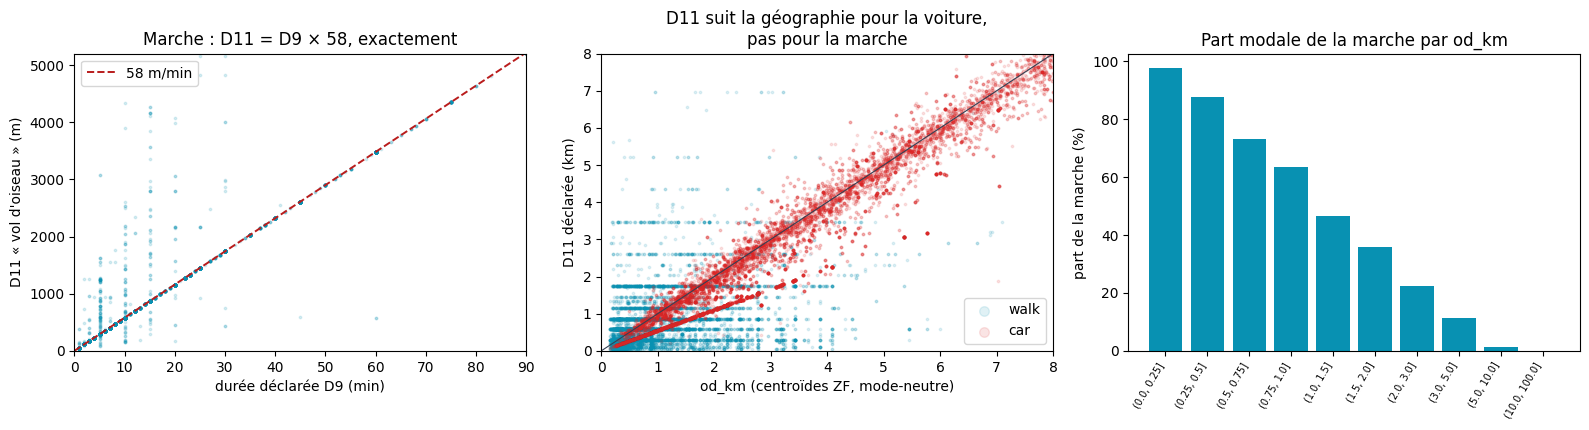

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

ax = axes[0]
ax.scatter(w_["duration_min"], w_["crow_km"]*1000, s=3, alpha=0.15, color=WALK)
xs = np.linspace(0, 90, 10); ax.plot(xs, 58*xs, color="#b91c1c", lw=1.4, ls="--", label="58 m/min")
ax.set_xlim(0, 90); ax.set_ylim(0, 5200)
ax.set_xlabel("durée déclarée D9 (min)"); ax.set_ylabel("D11 « vol d'oiseau » (m)")
ax.set_title("Marche : D11 = D9 × 58, exactement"); ax.legend()

ax = axes[1]
for m, c in [("walk", WALK), ("car", "#dc2626")]:
    s = full[msk & (full["mode"]==m)]
    ax.scatter(s["od_km"], s["crow_km"], s=3, alpha=0.12, color=c, label=m)
ax.plot([0,15],[0,15], color="#334155", lw=0.8)
ax.set_xlim(0,8); ax.set_ylim(0,8)
ax.set_xlabel("od_km (centroïdes ZF, mode-neutre)"); ax.set_ylabel("D11 déclarée (km)")
ax.set_title("D11 suit la géographie pour la voiture,\npas pour la marche")
ax.legend(markerscale=4)

ax = axes[2]
b = pd.cut(full.loc[msk,"od_km"], [0,.25,.5,.75,1,1.5,2,3,5,10,100])
g = full.loc[msk].groupby(b)["is_walk"].mean()*100
ax.bar(range(len(g)), g.values, color=WALK)
ax.set_xticks(range(len(g))); ax.set_xticklabels([str(i) for i in g.index], rotation=60, ha="right", fontsize=7)
ax.set_ylabel("part de la marche (%)"); ax.set_title("Part modale de la marche par od_km")
plt.tight_layout(); plt.show()

In [10]:
# Ce que coûte la fuite, chiffré : même modèle, seule la variable de distance change.
def _prep(d, cols):
    X = d[cols].copy()
    for c in X.columns:
        if not pd.api.types.is_numeric_dtype(X[c]) or pd.api.types.is_bool_dtype(X[c]):
            X[c] = X[c].astype("category")
    return X

_leak = full.dropna(subset=["od_km","crow_km","distance_km"]).copy()
_tr, _te = next(GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=0)
                .split(_leak, groups=_leak["hh_id"]))
_y = _leak["is_walk"].values
_base = ["age","gender","household_size","has_driving_license","has_pt_subscription",
         "number_of_cars","car_availability","has_bike","socioprofessional_class",
         "main_occupation","employed","studies","purpose","departure_hour"]

print(f"taux de base test = {_y[_te].mean():.4f}\n")
for lib, dvar in [("D12 (réseau du mode utilisé)","distance_km"),
                  ("D11 (« vol d'oiseau » déclaré)","crow_km"),
                  ("od_km (centroïdes ZF, mode-neutre)","od_km")]:
    X = _prep(_leak, _base + [dvar])
    m = lgb.LGBMClassifier(n_estimators=600, learning_rate=0.05, num_leaves=31,
                           min_child_samples=40, subsample=0.8, colsample_bytree=0.8,
                           is_unbalance=True, random_state=0, verbose=-1)
    m.fit(X.iloc[_tr], _y[_tr]); p = m.predict_proba(X.iloc[_te])[:,1]
    print(f"{lib:38s} PR-AUC = {average_precision_score(_y[_te], p):.4f}")
print("\n-> Les deux variables ProGEDO donnent une prédiction quasi parfaite d'un phénomène")
print("   social. C'est la signature d'une fuite, pas d'un bon modèle.")

taux de base test = 0.3122



D12 (réseau du mode utilisé)           PR-AUC = 0.9850


D11 (« vol d'oiseau » déclaré)         PR-AUC = 0.9846


od_km (centroïdes ZF, mode-neutre)     PR-AUC = 0.8044

-> Les deux variables ProGEDO donnent une prédiction quasi parfaite d'un phénomène
   social. C'est la signature d'une fuite, pas d'un bon modèle.


## 8. Échantillon d'analyse et protocole

On restreint aux déplacements dont `od_km` est calculable : périmètre d'enquête, 51 % des
déplacements. La part de la marche y monte mécaniquement à 31,5 % (les zones internes sont
les plus denses). **Cette restriction rend `trip_scope` (TYPD) dégénérée** — il ne reste
que des déplacements « Interne » — la variable est donc retirée du Block A.

In [11]:
df = full.dropna(subset=["od_km"]).copy()
print(f"N = {len(df)} déplacements | {df['hh_id'].nunique()} ménages "
      f"| part marche = {df['is_walk'].mean()*100:.2f}%")

BASELINE = ["age","gender","household_size","has_driving_license","has_pt_subscription",
            "number_of_cars","car_availability","has_bike","socioprofessional_class",
            "main_occupation","employed","studies","purpose","od_km","departure_hour"]

BLOCK_A = BASELINE + [
    # géométrie OD
    "same_zone",
    # socio-démographie étendue
    "education_level","hh_relationship","secondary_occupation","n_children",
    # équipement du ménage
    "n_bikes","bikes_per_person","n_motorbikes","cars_per_licensed",
    "housing_type","housing_tenure","car_night_parking",
    # contexte travail / études
    "works_from_home","commute_crow_km","car_avail_commute","car_parking_work",
    # contexte du déplacement
    "purpose_origin","n_stops_tour","survey_month","survey_weekday",
    # géographie
    "density_orig","density_dest","dist_center_orig_km","dist_center_dest_km",
]
BLOCK_B  = ["freq_bike","freq_motorbike","freq_car_driver","freq_transit","telework"]
NEW_IN_A = set(BLOCK_A) - set(BASELINE)

def prep(cols, d=None):
    X = (df if d is None else d)[cols].copy()
    for c in X.columns:
        if not pd.api.types.is_numeric_dtype(X[c]) or pd.api.types.is_bool_dtype(X[c]):
            X[c] = X[c].astype("category")     # LightGBM gère catégories et NaN nativement
    return X

tr, te = next(GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=0)
              .split(df, groups=df["hh_id"]))
y = df["is_walk"].values
print(f"train = {len(tr)} | test = {len(te)} | part marche test = {y[te].mean()*100:.2f}%")

N = 27886 déplacements | 7481 ménages | part marche = 31.54%
train = 20901 | test = 6985 | part marche test = 31.22%


### Part modale de la marche par variable candidate

In [12]:
for v in ["car_availability","housing_type","car_night_parking","main_occupation",
          "purpose","survey_month","freq_car_driver"]:
    s = df.groupby(v, dropna=False)["is_walk"].agg(part_marche_pct="mean", n="size")
    s["part_marche_pct"] = (s["part_marche_pct"]*100).round(2)
    print(f"\n--- {v} ---\n{s.sort_values('part_marche_pct', ascending=False).to_string()}")


--- car_availability ---
                  part_marche_pct      n
car_availability                        
none                        57.86   4039
some                        38.93   3707
all                         24.90  20140

--- housing_type ---
                   part_marche_pct      n
housing_type                             
Grand collectif              44.06   5863
Petit collectif              40.86   7192
Autre                        31.45    124
Individuel accolé            30.19   3713
Individuel isolé             19.21  10994

--- car_night_parking ---
                     part_marche_pct      n
car_night_parking                          
Autre                          80.00     10
Parc couvert public            63.89     72
NaN                            57.86   4039
Parc ciel ouvert               37.40   1361
Rue                            31.61   3341
Garage/box réservé             25.38  19063

--- main_occupation ---
                       part_marche_pct      n
mai

## 9. Modèles

In [13]:
def run(name, cols, d=None, split=None, target=None):
    d = df if d is None else d
    a, b = (tr, te) if split is None else split
    yy = y if target is None else target
    X = prep(cols, d)
    m = lgb.LGBMClassifier(n_estimators=600, learning_rate=0.05, num_leaves=31,
                           min_child_samples=40, subsample=0.8, colsample_bytree=0.8,
                           is_unbalance=True, random_state=0, verbose=-1)
    m.fit(X.iloc[a], yy[a])
    p  = m.predict_proba(X.iloc[b])[:, 1]
    ap = average_precision_score(yy[b], p)
    print(f"{name:38s} PR-AUC={ap:.4f}  ROC-AUC={roc_auc_score(yy[b], p):.4f}  ({len(cols)} vars)")
    return m, X, ap

print(f"=== Prédiction de la MARCHE (binaire) — taux de base = {y[te].mean():.4f} ===\n")
m0, X0, ap0 = run("0. Baseline (15 vars, od_km)", BASELINE)
mA, XA, apA = run("A. Block A (exogène étendu)",  BLOCK_A)
mB, XB, apB = run("A+B (avec habitudes déclarées)", BLOCK_A + BLOCK_B)
mS, XS, apS = run("A sans aucune distance OD",    [c for c in BLOCK_A if c != "od_km"])
print(f"\ngain A vs baseline : x{apA/ap0:.3f}   |   gain A+B vs A : x{apB/apA:.3f}")
print(f"retirer od_km coûte : x{apS/apA:.3f}   (pour mémoire, vélo : A x1.78, B x1.46)")

=== Prédiction de la MARCHE (binaire) — taux de base = 0.3122 ===



0. Baseline (15 vars, od_km)           PR-AUC=0.8038  ROC-AUC=0.9065  (15 vars)


A. Block A (exogène étendu)            PR-AUC=0.8548  ROC-AUC=0.9305  (39 vars)


A+B (avec habitudes déclarées)         PR-AUC=0.8628  ROC-AUC=0.9332  (44 vars)


A sans aucune distance OD              PR-AUC=0.8230  ROC-AUC=0.9111  (38 vars)

gain A vs baseline : x1.063   |   gain A+B vs A : x1.009
retirer od_km coûte : x0.963   (pour mémoire, vélo : A x1.78, B x1.46)


## 10. Analyse de Shapley — Block A

TreeSHAP sur le modèle Block A, variables exogènes uniquement.

In [14]:
expl = shap.TreeExplainer(mA)
samp = XA.iloc[te].sample(min(8000, len(te)), random_state=0)
sv   = expl.shap_values(samp)
if isinstance(sv, list): sv = sv[1]
if sv.ndim == 3:         sv = sv[:, :, 1]

imp_A = pd.Series(np.abs(sv).mean(0), index=samp.columns).sort_values(ascending=False)
tbl = imp_A.rename("mean_abs_shap").to_frame()
tbl["nouvelle"] = ["★" if k in NEW_IN_A else "" for k in tbl.index]
print("★ = variable absente du modèle actuel")
print("Classement complet : la queue de tableau sert au §14 « ce qui ne compte pas ».\n")
print(tbl.round(5).to_string())

★ = variable absente du modèle actuel
Classement complet : la queue de tableau sert au §14 « ce qui ne compte pas ».

                         mean_abs_shap nouvelle
od_km                          2.68541         
same_zone                      0.50047        ★
purpose_origin                 0.39186        ★
purpose                        0.38812         
departure_hour                 0.20217         
housing_type                   0.19853        ★
car_avail_commute              0.18928        ★
dist_center_dest_km            0.17037        ★
number_of_cars                 0.16565         
cars_per_licensed              0.16125        ★
dist_center_orig_km            0.15971        ★
car_night_parking              0.12239        ★
age                            0.10201         
survey_month                   0.09127        ★
density_orig                   0.08579        ★
commute_crow_km                0.08306        ★
density_dest                   0.08160        ★
n_bikes           

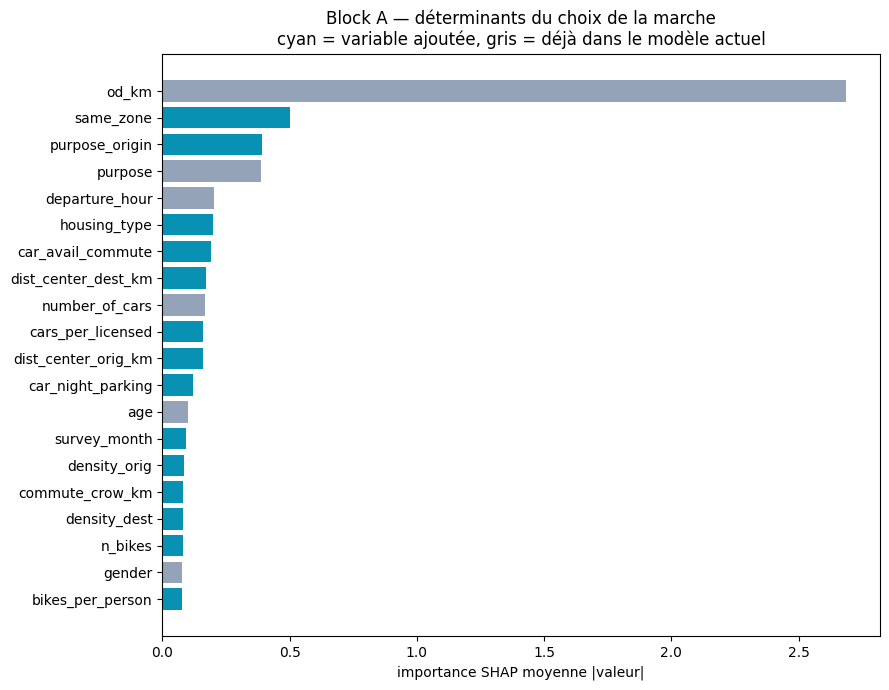

In [15]:
top = imp_A.head(20).iloc[::-1]
colors = [WALK if k in NEW_IN_A else "#94a3b8" for k in top.index]
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top.index, top.values, color=colors)
ax.set_xlabel("importance SHAP moyenne |valeur|")
ax.set_title("Block A — déterminants du choix de la marche\n"
             "cyan = variable ajoutée, gris = déjà dans le modèle actuel")
plt.tight_layout(); plt.show()

### Direction de l'effet (beeswarm)
Les catégorielles sont encodées en codes ordonnés — lire la magnitude, pas le signe de la couleur.

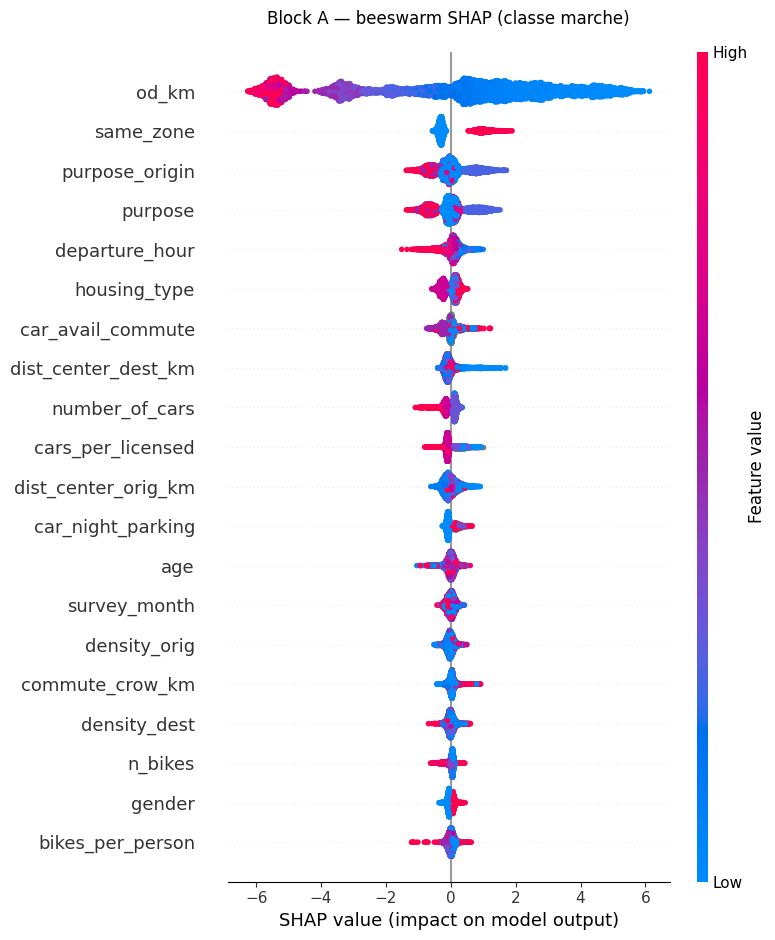

In [16]:
samp_num = samp.copy()
for c in samp_num.columns:
    if isinstance(samp_num[c].dtype, pd.CategoricalDtype):
        samp_num[c] = samp_num[c].cat.codes.replace(-1, np.nan)
shap.summary_plot(sv, samp_num, max_display=20, show=False)
plt.title("Block A — beeswarm SHAP (classe marche)", pad=20)
plt.tight_layout(); plt.show()

### Effet détaillé des principales catégorielles

In [17]:
sv_df = pd.DataFrame(sv, index=samp.index, columns=samp.columns)
for v in ["purpose","purpose_origin","housing_type","car_avail_commute",
          "car_night_parking","main_occupation","survey_month","education_level"]:
    g = pd.DataFrame({"shap": sv_df[v], "val": samp[v].astype(object)})
    r = g.groupby("val", dropna=False)["shap"].agg(shap_moyen="mean", n="size")
    r = r[r["n"] >= 30].sort_values("shap_moyen", ascending=False).round(4)
    print(f"\n--- {v} (SHAP > 0 = pousse vers la marche) ---\n{r.to_string()}")


--- purpose (SHAP > 0 = pousse vers la marche) ---
           shap_moyen     n
val                        
leisure        0.8176  1272
shop           0.1364   787
education     -0.0175   158
home          -0.0181  2969
other         -0.6719   726
work          -0.6877  1073

--- purpose_origin (SHAP > 0 = pousse vers la marche) ---
           shap_moyen     n
val                        
leisure        0.8043  1317
education      0.2357   155
home          -0.0438  2852
shop          -0.0836   869
other         -0.5665   726
work          -0.6975  1066

--- housing_type (SHAP > 0 = pousse vers la marche) ---
                   shap_moyen     n
val                                
Petit collectif        0.2226  1697
Individuel accolé      0.1152   995
Grand collectif        0.1114  1469
Autre                  0.0937    39
Individuel isolé      -0.2582  2785

--- car_avail_commute (SHAP > 0 = pousse vers la marche) ---
                    shap_moyen     n
val                              

### Effet des variables continues clés

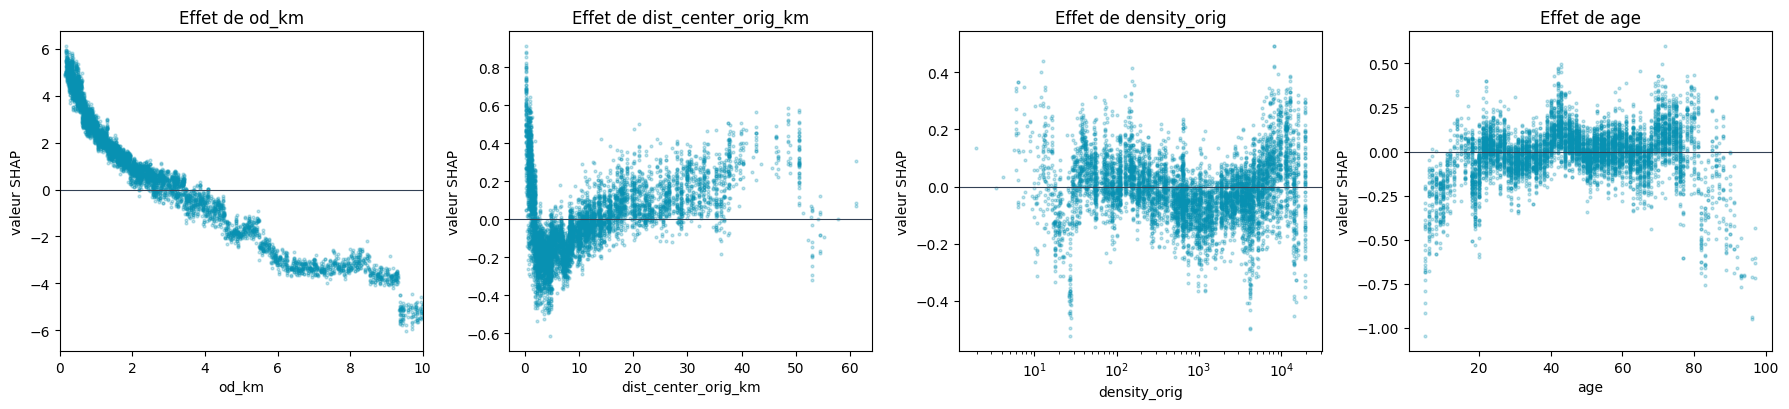

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
for ax, v in zip(axes, ["od_km", "dist_center_orig_km", "density_orig", "age"]):
    ax.scatter(samp[v], sv_df[v], s=4, alpha=0.25, color=WALK)
    ax.axhline(0, color="#334155", lw=0.8)
    ax.set_xlabel(v); ax.set_ylabel("valeur SHAP"); ax.set_title(f"Effet de {v}")
    if v == "od_km":        ax.set_xlim(0, 10)
    if v == "density_orig": ax.set_xscale("log")
plt.tight_layout(); plt.show()

## 11. À distance contrôlée — qui marche quand la marche est possible ?

`od_km` écrase tout le reste : c'est vrai mais peu actionnable. On restreint aux
déplacements de **2 km ou moins à vol d'oiseau**, où les quatre modes sont plausibles, et
on relit les SHAP. C'est le sous-échantillon sur lequel un levier de politique publique —
ou un trait de persona — a un sens.

In [19]:
short = df[df["od_km"] <= 2.0].copy()
trs, tes = next(GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=0)
                .split(short, groups=short["hh_id"]))
ys = short["is_walk"].values
print(f"od_km <= 2 km : N = {len(short)} | {short['hh_id'].nunique()} ménages "
      f"| part marche = {short['is_walk'].mean()*100:.1f}% | taux de base test = {ys[tes].mean():.4f}\n")

c0, Xc0, apc0 = run("0. Baseline (courts)", BASELINE,           short, (trs, tes), ys)
cA, XcA, apcA = run("A. Block A (courts)",  BLOCK_A,            short, (trs, tes), ys)
cB, XcB, apcB = run("A+B (courts)",         BLOCK_A + BLOCK_B,  short, (trs, tes), ys)
print(f"\ngain A vs baseline : x{apcA/apc0:.3f}   |   gain A+B vs A : x{apcB/apcA:.3f}")

od_km <= 2 km : N = 11972 | 4175 ménages | part marche = 62.2% | taux de base test = 0.6009



0. Baseline (courts)                   PR-AUC=0.8508  ROC-AUC=0.7889  (15 vars)


A. Block A (courts)                    PR-AUC=0.8941  ROC-AUC=0.8473  (39 vars)


A+B (courts)                           PR-AUC=0.9032  ROC-AUC=0.8582  (44 vars)

gain A vs baseline : x1.051   |   gain A+B vs A : x1.010


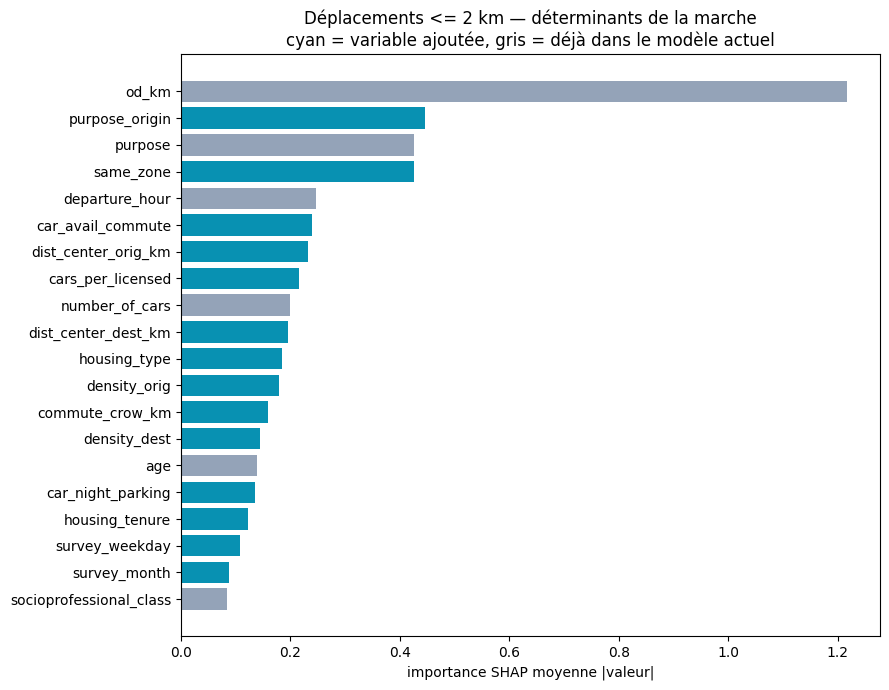

od_km                      1.21637
purpose_origin             0.44562
purpose                    0.42534
same_zone                  0.42501
departure_hour             0.24664
car_avail_commute          0.23881
dist_center_orig_km        0.23271
cars_per_licensed          0.21654
number_of_cars             0.19836
dist_center_dest_km        0.19578
housing_type               0.18514
density_orig               0.17978
commute_crow_km            0.15837
density_dest               0.14462
age                        0.13895
car_night_parking          0.13557
housing_tenure             0.12194
survey_weekday             0.10699
survey_month               0.08841
socioprofessional_class    0.08396
bikes_per_person           0.07738
n_bikes                    0.06974
works_from_home            0.06377
has_driving_license        0.05726
education_level            0.05569
household_size             0.05306
car_parking_work           0.05098
has_pt_subscription        0.04287
has_bike            

In [20]:
eS = shap.TreeExplainer(cA)
sS = XcA.iloc[tes].sample(min(8000, len(tes)), random_state=0)
vS = eS.shap_values(sS)
if isinstance(vS, list): vS = vS[1]
if vS.ndim == 3:         vS = vS[:, :, 1]

imp_S = pd.Series(np.abs(vS).mean(0), index=sS.columns).sort_values(ascending=False)
top = imp_S.head(20).iloc[::-1]
colors = [WALK if k in NEW_IN_A else "#94a3b8" for k in top.index]
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top.index, top.values, color=colors)
ax.set_xlabel("importance SHAP moyenne |valeur|")
ax.set_title("Déplacements <= 2 km — déterminants de la marche\n"
             "cyan = variable ajoutée, gris = déjà dans le modèle actuel")
plt.tight_layout(); plt.show()
print(imp_S.round(5).to_string())

In [21]:
svS = pd.DataFrame(vS, index=sS.index, columns=sS.columns)
for v in ["purpose","car_avail_commute","housing_type","car_night_parking","main_occupation"]:
    g = pd.DataFrame({"shap": svS[v], "val": sS[v].astype(object)})
    r = g.groupby("val", dropna=False)["shap"].agg(shap_moyen="mean", n="size")
    r = r[r["n"] >= 30].sort_values("shap_moyen", ascending=False).round(4)
    print(f"\n--- {v} sur <=2 km (SHAP > 0 = pousse vers la marche) ---\n{r.to_string()}")

print("\n" + "="*64)
print("Taux bruts sur le sous-échantillon <=2 km (à comparer aux SHAP ci-dessus)")
print("="*64)
short["_age_bin"] = pd.cut(short["age"], [0,11,17,25,40,60,75,120])
for v in ["_age_bin", "housing_type", "car_availability", "car_night_parking", "purpose"]:
    r = short.groupby(v, dropna=False)["is_walk"].agg(part_marche_pct=lambda x: 100*x.mean(), n="size").round(1)
    if v != "_age_bin": r = r.sort_values("part_marche_pct", ascending=False)
    print(f"\n--- {v} ---\n{r.to_string()}")


--- purpose sur <=2 km (SHAP > 0 = pousse vers la marche) ---
           shap_moyen     n
val                        
leisure        0.6437   587
home           0.1254  1266
education     -0.0834    78
shop          -0.1713   456
work          -0.9511   233
other         -1.1176   314

--- car_avail_commute sur <=2 km (SHAP > 0 = pousse vers la marche) ---
                    shap_moyen     n
val                                 
Non                     0.3671   466
Oui, partiel            0.3570    38
Oui, non utilisée       0.2572   197
NaN                     0.0735  1600
Oui, jusqu'au lieu     -0.5345   633

--- housing_type sur <=2 km (SHAP > 0 = pousse vers la marche) ---
                   shap_moyen    n
val                               
Petit collectif        0.1773  814
Grand collectif        0.0833  870
Individuel accolé     -0.0499  326
Individuel isolé      -0.3294  911

--- car_night_parking sur <=2 km (SHAP > 0 = pousse vers la marche) ---
                    shap_moyen

## 12. Block B — combien d'explication tient dans l'habitude déclarée ?

Pour le vélo, `freq_bike` devenait à elle seule la première variable du modèle et le
Block B captait 28,6 % de l'importance SHAP totale. Ici la fréquence d'usage de la marche
n'existe pas : le Block B ne peut agir que par **substitution** (« je conduis tous les
jours » ⇒ je ne marche pas). On mesure ce que ça vaut.

In [22]:
e2 = shap.TreeExplainer(mB)
s2 = XB.iloc[te].sample(min(8000, len(te)), random_state=0)
v2 = e2.shap_values(s2)
if isinstance(v2, list): v2 = v2[1]
if v2.ndim == 3:         v2 = v2[:, :, 1]

imp_B = pd.Series(np.abs(v2).mean(0), index=s2.columns).sort_values(ascending=False)
t2 = imp_B.rename("mean_abs_shap").to_frame()
t2["block"] = ["B (habitude)" if k in set(BLOCK_B) else "A" for k in t2.index]
print(t2.head(15).round(5).to_string())

part = imp_B[imp_B.index.isin(BLOCK_B)].sum()/imp_B.sum()
print(f"\nLe Block B capte {part*100:.1f}% de l'importance SHAP totale "
      f"avec {len(BLOCK_B)} variables sur {len(BLOCK_A)+len(BLOCK_B)}.")
print("Rappel vélo : 28.6% — et freq_bike arrivait en tête du modèle.")

                     mean_abs_shap         block
od_km                      2.68594             A
same_zone                  0.48799             A
purpose_origin             0.40051             A
freq_car_driver            0.39250  B (habitude)
purpose                    0.38623             A
freq_transit               0.22348  B (habitude)
dist_center_dest_km        0.19471             A
departure_hour             0.19051             A
number_of_cars             0.18758             A
housing_type               0.16598             A
dist_center_orig_km        0.16223             A
car_avail_commute          0.11696             A
age                        0.10880             A
cars_per_licensed          0.10652             A
freq_bike                  0.10465  B (habitude)

Le Block B capte 11.1% de l'importance SHAP totale avec 5 variables sur 44.
Rappel vélo : 28.6% — et freq_bike arrivait en tête du modèle.


## 13. Export

In [23]:
export_cols = (["hh_id","ZF","ECH","PER","NDEP","mode","is_walk","weight_person"]
               + BLOCK_A + BLOCK_B)
out = df[[c for c in dict.fromkeys(export_cols)]].reset_index(drop=True)
path = OUT_DIR/"progedo_walk_exploration.csv"
out.to_csv(path, index=False)
imp_A.rename("mean_abs_shap").to_csv(OUT_DIR/"progedo_walk_shap_blockA.csv")
imp_S.rename("mean_abs_shap").to_csv(OUT_DIR/"progedo_walk_shap_short2km.csv")
print("Écrits :")
print(" -", path, out.shape)
print(" -", OUT_DIR/"progedo_walk_shap_blockA.csv")
print(" -", OUT_DIR/"progedo_walk_shap_short2km.csv")

Écrits :
 - /Users/yvesb/Documents/Projects/llm-agents-gama/scripts/progedo_logit/progedo_walk_exploration.csv (27886, 52)
 - /Users/yvesb/Documents/Projects/llm-agents-gama/scripts/progedo_logit/progedo_walk_shap_blockA.csv
 - /Users/yvesb/Documents/Projects/llm-agents-gama/scripts/progedo_logit/progedo_walk_shap_short2km.csv


## 14. Lecture des résultats

### Le résultat principal est méthodologique : deux variables ProGEDO sont inutilisables

Pour la marche, `D12` et `D11` donnent une **PR-AUC de 0.98** contre un taux de base de
0.31. Aucun modèle de choix modal ne prédit un comportement social à ce niveau : c'est une
fuite. Le §7 en donne la cause exacte — **D11, documentée comme distance à vol d'oiseau,
vaut `durée déclarée × 58 m/min` pour tous les déplacements à pied**. Rapport constant à
58 sur l'ensemble des quantiles, ~250 valeurs distinctes contre ~9 800 pour la voiture,
corrélation avec la géographie réelle de 0.40 pour la marche contre 0.995 pour les autres
modes. D11 n'encode pas une distance, elle encode une durée de marche — c'est-à-dire la
cible.

Avec `od_km` reconstruite depuis les centroïdes de zones fines, la PR-AUC retombe à
**0.80–0.86**, une valeur crédible.

⚠️ **Conséquence pour le notebook vélo.** Il utilise `crow_km` = D11 dans son Block A. Les
lignes « marche » y portent la même valeur contaminée, ce qui permet au modèle vélo
d'identifier parfaitement les trajets à pied et donc de les exclure de la classe vélo. La
PR-AUC vélo de 0.410 est probablement **surestimée**. Le classement SHAP, lui, est
vraisemblablement robuste — la fuite bénéficie à une variable déjà dominante — mais un
rejeu du notebook vélo avec `od_km` serait la vérification honnête à faire.

### La marche est un mode contraint, pas un mode choisi

Une fois la fuite corrigée, le Block A n'apporte que **×1.06** sur la baseline (vélo :
×1.78), et retirer toute distance OD ne coûte que ×0.96. Autrement dit : sur l'ensemble
des déplacements, la marche est décidée par la **géométrie du déplacement**, et
l'enrichissement du persona n'y change presque rien. `od_km` pèse 2.69 en SHAP moyen quand
la deuxième variable, `same_zone`, pèse 0.50 — un rapport de 5.

C'est l'inverse du diagnostic vélo, et c'est une bonne nouvelle pour la simulation : le
choix de la marche est **modélisable sans persona riche**, à condition de fournir à l'agent
une distance OD correcte.

### À 2 km ou moins, ce qui compte vraiment

Sur les ~12 000 déplacements de moins de 2 km (62,2 % de marche), les leviers apparaissent :

1. **Le motif, à l'origine comme à la destination** (rangs 2 et 3, SHAP 0.45 et 0.43). Le
   loisir pousse fortement vers la marche (+0.64), le travail (−0.95) et « autre » (−1.12)
   fortement contre. La marche est le mode du temps non contraint.
2. **`car_avail_commute` (P16, rang 6)** — exactement la même variable clé que pour le
   vélo, avec le même sens : « voiture disponible jusqu'au lieu de travail » −0.54,
   « pas de voiture » +0.37, « voiture disponible mais non utilisée » +0.26. Les modes
   actifs se décident contre la voiture, pas pour eux-mêmes.
3. **`cars_per_licensed` et `number_of_cars` (rangs 8 et 9)**, tandis que
   `car_availability` — la catégorielle grossière du modèle actuel — sort du top 20 et
   pèse 0.024 dans le modèle sur échantillon complet. Même leçon que `has_bike` vs
   `n_bikes` côté vélo : **l'agrégation en catégories détruit le signal**. En taux bruts
   l'écart est pourtant net (80,4 % de marche sans voiture contre 54,8 % quand il y a une
   voiture par titulaire du permis) : c'est le comptage fin qui porte l'information, pas
   l'étiquette.
4. **`housing_type` (rang 11)** — en taux bruts, 70,6 % de marche en grand collectif contre
   47,0 % en individuel isolé. Le SHAP redistribue un peu ce classement à conditions
   égales (petit collectif +0.18, grand collectif +0.08, individuel isolé −0.33) : une
   partie de l'avantage du grand collectif est en réalité portée par la densité et la
   position dans l'agglomération, avec lesquelles il est confondu. Le signal propre du
   logement reste net dans un seul sens — **la maison isolée décourage la marche**.
5. **`car_night_parking` (rang 16)** — l'hypothèse du **coût de sortie** se vérifie :
   garage réservé −0.11, stationnement en parc à ciel ouvert +0.10, rue +0.17. Quand
   reprendre la voiture coûte une place de stationnement au retour, on marche. Variable
   absente du modèle actuel et jamais discutée jusqu'ici.
6. **L'âge est en U** : 71,7 % de marche chez les 17–25 ans, 70,0 % chez les 75 ans et
   plus, contre 56,9 % chez les 40–60 ans. Un effet non monotone qu'un logit linéaire
   manquerait entièrement.

### Ce qui ne compte pas
`n_stops_tour` (SHAP 0.0006), `studies`, `employed` et `secondary_occupation` sont
d'importance nulle. `main_occupation` pèse 0.039 alors que ses taux bruts vont de 45 % à
73 % : tout son signal est absorbé par l'âge, le motif et la géographie. À écarter du
persona — c'est de la redondance coûteuse en tokens.

### Ce que le Block B raconte sur l'architecture de l'agent

Le Block B ne capte que **11,1 % de l'importance SHAP** (14,4 % sur les trajets courts) et
n'améliore la PR-AUC que de ×1.01, contre 28,6 % et ×1.46 pour le vélo. Deux lectures se
superposent, et il faut les tenir séparées :

- **Lecture prudente.** L'écart est en partie un artefact de collecte : `P19`, la fréquence
  d'usage de la marche, est **intégralement vide** dans le fichier Toulouse 2023. Le
  Block B marche ne contient que des fréquences de modes concurrents. On ne peut donc
  **pas** conclure directement que la marche est moins habituelle que le vélo — on n'a
  pas mesuré son habitude.
- **Lecture de fond.** Ce que l'on peut affirmer, c'est que le Block A **suffit** pour la
  marche : 0.855 de PR-AUC sans aucune habitude déclarée, là où le vélo plafonnait à
  0.410. La variance de la marche est structurelle et géométrique ; celle du vélo était
  pour un tiers individuelle.

Conséquence pour le dispositif mémoire : **la LTM est un levier pour le vélo, pas pour la
marche.** Un agent sans mémoire des trajets passés a un plafond sur le vélo ; il n'en a
pratiquement pas sur la marche, pourvu qu'il dispose de la distance OD, du motif et de la
disponibilité de la voiture. Cela suggère de ne pas dépenser de budget de contexte à
raconter l'historique piéton d'un agent.

### Suites possibles
- **Rejouer le notebook vélo avec `od_km`** pour mesurer la part de la PR-AUC vélo
  imputable à la fuite D11.
- **Ajouter au persona** les trois variables rentables et simulables : nombre de voitures
  par titulaire du permis (au lieu de la catégorie `car_availability`), type d'habitat,
  et mode de stationnement nocturne de la voiture.
- **Fix 2 (choice set OTP)** — d'autant plus pertinent ici : router chaque paire OD pour
  les 4 modes fournirait une distance et un temps réels *par mode*, ce qui remplacerait
  `od_km` par la grandeur que l'agent voit réellement dans son prompt, et réglerait
  définitivement le problème de fuite qui affecte les deux notebooks.